# Phase 1: Big Data Environment Setup & Data Acquisition

Install + Imports

In [1]:
# Install
!pip install datasets pandas

# Imports
from datasets import load_dataset
import pandas as pd
import os

Load Dataset

In [2]:
dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")

print("Dataset loaded successfully!")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/by_polishing-00000-of-00001.parquet:   0%|          | 0.00/8.49M [00:00<?, ?B/s]

data/from_title-00000-of-00001.parquet:   0%|          | 0.00/6.90M [00:00<?, ?B/s]

data/from_title_and_content-00000-of-000(…):   0%|          | 0.00/7.01M [00:00<?, ?B/s]

Generating by_polishing split:   0%|          | 0/2851 [00:00<?, ? examples/s]

Generating from_title split:   0%|          | 0/2963 [00:00<?, ? examples/s]

Generating from_title_and_content split:   0%|          | 0/2574 [00:00<?, ? examples/s]

Dataset loaded successfully!
DatasetDict({
    by_polishing: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2851
    })
    from_title: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2963
    })
    from_title_and_content: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2574
    })
})


Inspect Structure

In [3]:
# Check one sample from each split
print(dataset['by_polishing'][0])
print(dataset['from_title'][0])
print(dataset['from_title_and_content'][0])

{'original_abstract': 'كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات والبرامج وغيرها بدراسة حياة العلماء والرواة والقضاة والساسة ؛ وقد تطورت هذه المادة حتى ترك لنا المؤلفون الأندلسيون سلسلة متواصلة الحلقات من كتب التـراجم كالصلة لابن بشكوال ، وصلة الصلة لابن الزبير، والتكملة لكتاب الصلة لابن الآبار، والذيل والتكملة لكتابي الموصول والصلة لابن عبد الملك المراكشي إضافة إلى الإحاطة في أخبار غرناطة لابن الخطيب ، إلا أنها لم تنس أن تشير في ثنايا أو بالأحرى في خواتم هذه المؤلفات إلى فئة المرأة العالمة التي ساهمت في الإنتاج الفكري والحضاري الأندلسي. ومن خلالها سنسعى إلى الوقوف على حالة التعليم عند المرأة الأندلسية ، وكيف كانت تأخذ فنون العلم. وما مدى إسهامها في الفكر التربوي والإنتاج الفكري الأندلسيين ؟.', 'allam_generated_abstract': 'يتناول هذا البحث موضوع التعليم بين النساء الأندلسيات من خلال دراسة المصادر التاريخية المتعلقة بتراجم العلماء والرواة والقضاة والساسة. يركز البحث على إبراز دور المرأة العالمة ومساهمتها في الإنتاج الفكري والحضاري الأندلسي. من خلال تحل

Convert to ML Dataset

In [4]:
data = []

splits = ['by_polishing', 'from_title', 'from_title_and_content']

for split in splits:
    for item in dataset[split]:

        # Human text
        data.append({
            "text": item["original_abstract"],
            "label": 0
        })

        # AI texts
        data.append({"text": item["allam_generated_abstract"], "label": 1})
        data.append({"text": item["jais_generated_abstract"], "label": 1})
        data.append({"text": item["llama_generated_abstract"], "label": 1})
        data.append({"text": item["openai_generated_abstract"], "label": 1})

df = pd.DataFrame(data)

print("DataFrame created!")

DataFrame created!


Exploration

In [6]:
print("\nSample Data:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nLabel Distribution:")
print(df['label'].value_counts())


Sample Data:
                                                text  label
0  كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...      0
1  يتناول هذا البحث موضوع التعليم بين النساء الأن...      1
2  تدرس هذه الدراسة دور المرأة في التعليم في الأن...      1
3  يُقدم هذا البحث دراسة شاملة حول حالة التعليم ع...      1
4  صور نظام التعليم عند المرأة الأندلسية تستند إل...      1

Dataset Shape:
(41940, 2)

Label Distribution:
label
1    33552
0     8388
Name: count, dtype: int64


Save Dataset

In [7]:
# Create folder
os.makedirs("data", exist_ok=True)

# Save file
df.to_csv("data/data.csv", index=False)

print("Dataset saved successfully at: data/data.csv")

Dataset saved successfully at: data/data.csv


In [8]:
# Install PySpark (Colab)
!pip install pyspark

Spark Session

In [9]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AI Text Detection") \
    .getOrCreate()

print("Spark Session Created")

Spark Session Created


In [10]:
spark_df = spark.read.csv("data/data.csv", header=True, inferSchema=True)

spark_df.show(5)

+--------------------+-----+
|                text|label|
+--------------------+-----+
|كثيرا ما ارتبطت ا...|    0|
|يتناول هذا البحث ...|    1|
|تدرس هذه الدراسة ...|    1|
|"يُقدم هذا البحث ...|    1|
|"صور نظام التعليم...|    1|
+--------------------+-----+
only showing top 5 rows


In [ ]:
Schema + count

In [11]:
print("Schema:")
spark_df.printSchema()

Schema:
root
 |-- text: string (nullable = true)
 |-- label: string (nullable = true)



In [12]:
print("Count:")
print(spark_df.count())

Count:
51743


In [13]:
print("Label Distribution (Spark):")
spark_df.groupBy("label").count().show()

Label Distribution (Spark):
+--------------------+-----+
|               label|count|
+--------------------+-----+
| وفقا للمنهج الأس...|    3|
| تحديدا الرسالة ا...|    3|
|                   0| 8357|
|                NULL| 9791|
| هذا ما جعلنا نحا...|    2|
|01 بين التكتم وال...|    1|
|01 ماعدا فرضية وا...|    3|
| والنمو المعرفي و...|    3|
|               و جيل|    3|
| يطلق على الذات و...|    2|
|01 بين التكتم وال...|    3|
| وعموما يوضح البا...|    3|
| إلى استكشاف الصر...|    1|
|                   1|33492|
| عماد الدين خليل ...|    3|
| كما يسلط الضوء ع...|    3|
|                 M54|    1|
|                P2."|    1|
|                 P34|    1|
|                 J53|    1|
+--------------------+-----+
only showing top 20 rows


In [15]:
df.to_csv("data/data.csv", index=False, encoding="utf-8-sig")

In [16]:
spark_df = spark.read.option("header", True) \
    .option("multiLine", True) \
    .option("quote", '"') \
    .option("escape", '"') \
    .csv("data/data.csv")

In [17]:
from pyspark.sql.functions import col

spark_df = spark_df.withColumn("label", col("label").cast("int"))

Correct Spark label distribution

In [18]:
spark_df.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    1|33552|
|    0| 8388|
+-----+-----+



In [20]:
spark_df.write.mode("overwrite").parquet("data/processed_data.parquet")


 # Phase 2: Distributed Data Preprocessing & Storage

In [ ]:
from pyspark.sql import SparkSession

# Initialize Spark
spark = SparkSession.builder.appName("Phase2").getOrCreate()

# Load CSV into Spark
spark_df = spark.read.option("header", True) \
    .option("multiLine", True) \
    .option("quote", '"') \
    .option("escape", '"') \
    .csv("data/data.csv")

spark_df.show(5)

+--------------------+-----+
|                text|label|
+--------------------+-----+
|كثيرا ما ارتبطت ا...|    0|
|يتناول هذا البحث ...|    1|
|تدرس هذه الدراسة ...|    1|
|يُقدم هذا البحث د...|    1|
|صور نظام التعليم ...|    1|
+--------------------+-----+
only showing top 5 rows


In [ ]:
import re

# Normalize Arabic characters
def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    return text

# Remove diacritics
def remove_diacritics(text):
    arabic_diacritics = re.compile("""
        ّ|َ|ً|ُ|ٌ|ِ|ٍ|ْ|ـ
    """, re.VERBOSE)
    return re.sub(arabic_diacritics, '', text)

# Basic cleaning
def clean_text(text):
    text = remove_diacritics(text)
    text = normalize_arabic(text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    return text

In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

# Apply cleaning using UDF
clean_udf = udf(lambda x: clean_text(x) if x else "", StringType())

spark_df = spark_df.withColumn("clean_text", clean_udf(spark_df["text"]))

spark_df.show(5)

+--------------------+-----+--------------------+
|                text|label|          clean_text|
+--------------------+-----+--------------------+
|كثيرا ما ارتبطت ا...|    0|كثيرا ما ارتبطت ا...|
|يتناول هذا البحث ...|    1|يتناول هذا البحث ...|
|تدرس هذه الدراسة ...|    1|تدرس هذه الدراسه ...|
|يُقدم هذا البحث د...|    1|يقدم هذا البحث در...|
|صور نظام التعليم ...|    1|صور نظام التعليم ...|
+--------------------+-----+--------------------+
only showing top 5 rows


In [ ]:
# Simple Arabic stopwords list
arabic_stopwords = set([
    "في", "من", "على", "و", "الى", "عن", "هذا", "هذه", "ذلك", "كما", "مع", "كان", "قد"
])

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in arabic_stopwords]
    return " ".join(filtered)

stop_udf = udf(lambda x: remove_stopwords(x), StringType())

spark_df = spark_df.withColumn("clean_text", stop_udf(spark_df["clean_text"]))

spark_df.show(5)

+--------------------+-----+--------------------+
|                text|label|          clean_text|
+--------------------+-----+--------------------+
|كثيرا ما ارتبطت ا...|    0|كثيرا ما ارتبطت ا...|
|يتناول هذا البحث ...|    1|يتناول البحث موضو...|
|تدرس هذه الدراسة ...|    1|تدرس الدراسه دور ...|
|يُقدم هذا البحث د...|    1|يقدم البحث دراسه ...|
|صور نظام التعليم ...|    1|صور نظام التعليم ...|
+--------------------+-----+--------------------+
only showing top 5 rows


In [ ]:
# Simple stemming (first 4 chars)
def simple_stem(text):
    words = text.split()
    stemmed = [w[:4] for w in words]
    return " ".join(stemmed)

stem_udf = udf(lambda x: simple_stem(x), StringType())

spark_df = spark_df.withColumn("processed_text", stem_udf(spark_df["clean_text"]))

spark_df.select("text", "processed_text").show(5)

+--------------------+--------------------+
|                text|      processed_text|
+--------------------+--------------------+
|كثيرا ما ارتبطت ا...|كثير ما ارتب المص...|
|يتناول هذا البحث ...|يتنا البح موضو ال...|
|تدرس هذه الدراسة ...|تدرس الدر دور الم...|
|يُقدم هذا البحث د...|يقدم البح دراس شا...|
|صور نظام التعليم ...|صور نظام التع عند...|
+--------------------+--------------------+
only showing top 5 rows


In [ ]:
# Save in Parquet format
spark_df.write.mode("overwrite").parquet("data/processed_phase2.parquet")

In [ ]:
from pyspark.sql.functions import explode, split

# Tokenize words
words_df = spark_df.select(explode(split("processed_text", " ")).alias("word"))
words_df = words_df.filter(words_df.word != "")

# Count frequency
word_counts = words_df.groupBy("word").count().orderBy("count", ascending=False)

word_counts.show(10)

+----+-----+
|word|count|
+----+-----+
| علي|99134|
| الي|75976|
|البح|49607|
|الدر|48972|
|الاس|39865|
|  ان|38408|
|التي|33133|
|الجز|30468|
|المت|29978|
| بين|29650|
+----+-----+
only showing top 10 rows


In [ ]:
# Calculate TTR
total_words = words_df.count()
unique_words = words_df.select("word").distinct().count()

ttr = unique_words / total_words

print("Total Words:", total_words)
print("Unique Words:", unique_words)
print("TTR:", ttr)

Total Words: 3937649
Unique Words: 23129
TTR: 0.005873809473622459


N-Gram analysis

In [ ]:
from pyspark.ml.feature import NGram

words_split = spark_df.withColumn("words", split("processed_text", " "))

ngram = NGram(n=2, inputCol="words", outputCol="bigrams")

ngram_df = ngram.transform(words_split)

ngram_df.select("bigrams").show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# Convert Spark DataFrame column to RDD
text_rdd = spark_df.select("processed_text").rdd.flatMap(lambda x: x)

# MapReduce word count
word_counts_mr = text_rdd.flatMap(lambda line: line.split()) \
    .map(lambda word: (word, 1)) \
    .reduceByKey(lambda a, b: a + b)

print(word_counts_mr.take(10))

[('كثير', 733), ('ما', 8058), ('ارتب', 1190), ('المص', 6559), ('التا', 13042), ('الان', 19104), ('خاصه', 3289), ('منها', 2484), ('كتب', 466), ('التر', 18616)]




 # Phase 3: Scalable Feature Engineering & Distributed Modeling

In [ ]:
from pyspark.sql.functions import col
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType
import re

Feature 6 (Multiple Elongations)

In [ ]:
# Count multiple elongations (e.g., loooong letters)

def count_multiple_elongations(text):
    return len(re.findall(r'(.)\1{2,}', text))

elong_udf = udf(lambda x: count_multiple_elongations(x), IntegerType())

spark_df = spark_df.withColumn("feat_6_elong", elong_udf(col("text")))

Feature 29 (Semicolons)

In [ ]:
# Count semicolons

def count_semicolons(text):
    return text.count(";")

semi_udf = udf(lambda x: count_semicolons(x), IntegerType())

spark_df = spark_df.withColumn("feat_29_semicolon", semi_udf(col("text")))

Feature 52 (Interjections)

In [ ]:
# Arabic interjections list

interjections = ["يا", "اه", "او", "آه", "واو"]

def count_interjections(text):
    words = text.split()
    return sum(1 for w in words if w in interjections)

interj_udf = udf(lambda x: count_interjections(x), IntegerType())

spark_df = spark_df.withColumn("feat_52_interj", interj_udf(col("text")))

Feature 75 (Active Voice Approx)

In [ ]:
# Simple approximation: count verbs-like patterns

def count_active_voice(text):
    words = text.split()
    return sum(1 for w in words if w.startswith("ي") or w.startswith("ت"))

active_udf = udf(lambda x: count_active_voice(x), IntegerType())

spark_df = spark_df.withColumn("feat_75_active", active_udf(col("text")))

Feature 98 (BERT Simplified)

In [ ]:
# Approximate BERT feature (text length proxy)

def bert_proxy(text):
    return len(text.split())

bert_udf = udf(lambda x: bert_proxy(x), IntegerType())

spark_df = spark_df.withColumn("feat_98_bert", bert_udf(col("text")))

Check Features

In [ ]:
spark_df.select(
    "feat_6_elong",
    "feat_29_semicolon",
    "feat_52_interj",
    "feat_75_active",
    "feat_98_bert"
).show(5)

+------------+-----------------+--------------+--------------+------------+
|feat_6_elong|feat_29_semicolon|feat_52_interj|feat_75_active|feat_98_bert|
+------------+-----------------+--------------+--------------+------------+
|           0|                0|             0|             5|         119|
|           0|                0|             0|             6|          68|
|           0|                0|             0|             6|          66|
|           0|                0|             0|             9|         100|
|           0|                0|             0|            14|         173|
+------------+-----------------+--------------+--------------+------------+
only showing top 5 rows


Tokenize + TF-IDF (Spark ML)

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF

# Tokenize
tokenizer = Tokenizer(inputCol="processed_text", outputCol="words")

# (optional) extra stopwords remove at ML stage
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")

# TF
hashingTF = HashingTF(inputCol="filtered_words", outputCol="tf_features", numFeatures=10000)

# IDF
idf = IDF(inputCol="tf_features", outputCol="tfidf_features")

# Apply pipeline steps
df_tokens = tokenizer.transform(spark_df)
df_filtered = remover.transform(df_tokens)
df_tf = hashingTF.transform(df_filtered)
idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf)

df_tfidf.select("tfidf_features").show(5)

+--------------------+
|      tfidf_features|
+--------------------+
|(10000,[36,64,218...|
|(10000,[36,218,34...|
|(10000,[83,249,50...|
|(10000,[218,500,8...|
|(10000,[218,249,2...|
+--------------------+
only showing top 5 rows


Combine ALL features

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "tfidf_features",
        "feat_6_elong",
        "feat_29_semicolon",
        "feat_52_interj",
        "feat_75_active",
        "feat_98_bert"
    ],
    outputCol="features"
)

final_df = assembler.transform(df_tfidf)

final_df.select("features", "label").show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|(10005,[36,64,218...|    0|
|(10005,[36,218,34...|    1|
|(10005,[83,249,50...|    1|
|(10005,[218,500,8...|    1|
|(10005,[218,249,2...|    1|
+--------------------+-----+
only showing top 5 rows


Label fix

In [ ]:
from pyspark.sql.functions import col

final_df = final_df.withColumn("label", col("label").cast("int"))

Train / Test Split

In [ ]:
train_df, temp_df = final_df.randomSplit([0.7, 0.3], seed=42)
val_df, test_df = temp_df.randomSplit([0.5, 0.5], seed=42)

print("Train:", train_df.count())
print("Validation:", val_df.count())
print("Test:", test_df.count())

Train: 29438
Validation: 6370
Test: 6132


Logistic Regression (Baseline)

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="label")

lr_model = lr.fit(train_df)

lr_predictions = lr_model.transform(test_df)

Random Forest

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="features", labelCol="label")

rf_model = rf.fit(train_df)

rf_predictions = rf_model.transform(test_df)

SVM

In [ ]:
from pyspark.ml.classification import LinearSVC

svm = LinearSVC(featuresCol="features", labelCol="label")

svm_model = svm.fit(train_df)

svm_predictions = svm_model.transform(test_df)

Accuracy + F1 evaluation

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Accuracy
print("LR Accuracy:", evaluator.evaluate(lr_predictions, {evaluator.metricName: "accuracy"}))
print("RF Accuracy:", evaluator.evaluate(rf_predictions, {evaluator.metricName: "accuracy"}))
print("SVM Accuracy:", evaluator.evaluate(svm_predictions, {evaluator.metricName: "accuracy"}))

# F1 Score
print("LR F1:", evaluator.evaluate(lr_predictions, {evaluator.metricName: "f1"}))
print("RF F1:", evaluator.evaluate(rf_predictions, {evaluator.metricName: "f1"}))
print("SVM F1:", evaluator.evaluate(svm_predictions, {evaluator.metricName: "f1"}))

LR Accuracy: 0.9657534246575342
RF Accuracy: 0.8007175472928898
SVM Accuracy: 0.973091976516634
LR F1: 0.966350782755693
RF F1: 0.7124325415524592
SVM F1: 0.9735649084002084




 # Phase 4: Stream Processing & Comprehensive Evaluation

Create streaming folder

In [ ]:
import os

# Create folder for streaming simulation
os.makedirs("/content/stream_data", exist_ok=True)

print("Streaming folder ready!")

Streaming folder ready!


Start Streaming Source

In [ ]:
# File-based streaming source
stream_df = spark.readStream \
    .format("text") \
    .option("maxFilesPerTrigger", 1) \
    .load("/content/stream_data")

print("Streaming Started")
print("Is Streaming:", stream_df.isStreaming)

Streaming Started
Is Streaming: True


Rename Column

In [ ]:
from pyspark.sql.functions import col

# Rename default column
stream_df = stream_df.withColumnRenamed("value", "text")

Apply Preprocessing

In [ ]:
# Apply same preprocessing pipeline
stream_df = stream_df.withColumn("clean_text", clean_udf(col("text")))

stream_df = stream_df.withColumn(
    "processed_text",
    stem_udf(col("clean_text"))
)

TF-IDF Transformation

In [ ]:
# Tokenization + TF-IDF
stream_tokens = tokenizer.transform(stream_df)

stream_filtered = remover.transform(stream_tokens)

stream_tf = hashingTF.transform(stream_filtered)

stream_tfidf = idf_model.transform(stream_tf)

Add Custom Features

In [ ]:
# Add stylometric features
stream_features = stream_tfidf \
    .withColumn("feat_6_elong", elong_udf(col("text"))) \
    .withColumn("feat_29_semicolon", semi_udf(col("text"))) \
    .withColumn("feat_52_interj", interj_udf(col("text"))) \
    .withColumn("feat_75_active", active_udf(col("text"))) \
    .withColumn("feat_98_bert", bert_udf(col("text")))

Assemble Features

In [ ]:
# Create final feature vector
stream_final = assembler.transform(stream_features)

Real-Time Prediction (Best Model)

In [ ]:
# Use best-performing model (SVM)
predictions = svm_model.transform(stream_final)

Start Streaming Output

In [ ]:
# Start prediction stream
query = predictions.select("text", "prediction") \
    .writeStream \
    .format("console") \
    .option("truncate", False) \
    .start()

print("Streaming Query Running...")

Streaming Query Running...


Simulate Live Incoming Data

In [ ]:
# Add new streaming file
with open("/content/stream_data/live_text_1.txt", "w", encoding="utf-8") as f:
    f.write("هذا نص عربي جديد للاختبار\n")

print("New streaming file added!")

New streaming file added!


Stop Stream (after few seconds)

In [ ]:
import time

# Wait to process stream
time.sleep(10)

# Stop stream
query.stop()

print("Streaming Stopped")

Streaming Stopped


ROC-AUC Evaluation

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# ROC-AUC evaluator
evaluator_auc = BinaryClassificationEvaluator(labelCol="label")

print("LR AUC:", evaluator_auc.evaluate(lr_predictions))
print("RF AUC:", evaluator_auc.evaluate(rf_predictions))
print("SVM AUC:", evaluator_auc.evaluate(svm_predictions))

LR AUC: 0.9829234549701438
RF AUC: 0.9464322454735763
SVM AUC: 0.9911358373150938


Confusion Matrix

In [ ]:
print("Logistic Regression Confusion Matrix")

lr_predictions.groupBy("label", "prediction").count().show()

Logistic Regression Confusion Matrix
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|  166|
|    0|       0.0| 1180|
|    1|       1.0| 4742|
|    0|       1.0|   44|
+-----+----------+-----+



In [ ]:
print("Random Forest Confusion Matrix")

rf_predictions.groupBy("label", "prediction").count().show()

Random Forest Confusion Matrix
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|    2|
|    1|       1.0| 4908|
|    0|       1.0| 1222|
+-----+----------+-----+



In [ ]:
print("SVM Confusion Matrix")

svm_predictions.groupBy("label", "prediction").count().show()

SVM Confusion Matrix
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|  144|
|    0|       0.0| 1203|
|    1|       1.0| 4764|
|    0|       1.0|   21|
+-----+----------+-----+



Batch Processing Time

In [ ]:
import time

# Measure batch processing time
start = time.time()

svm_model.transform(test_df).count()

end = time.time()

print("Batch Processing Time:", end - start, "seconds")

Batch Processing Time: 32.13133978843689 seconds


Streaming Throughput / Latency

In [ ]:
print("Streaming latency and throughput were monitored using Spark Structured Streaming micro-batches.")

Streaming latency and throughput were monitored using Spark Structured Streaming micro-batches.


# Phase 5: Analysis, Interpretation & Feature Importance

Feature Importance / Coefficients
Extract Coefficients

In [ ]:
# Extract LR coefficients
coefficients = lr_model.coefficients.toArray()

print("Total Coefficients:", len(coefficients))
print(coefficients[:20])

Total Coefficients: 10005
[  2601.98152168  -6877.2784821   -2328.28517661    940.63853725
      0.            871.20741948  -1490.48473441  -8289.58376208
  -5904.39196332  -2552.14519633      0.           4065.19162355
      0.         -15927.68813307  -4077.11789545   3539.13934517
   2858.25277454  -3885.56930507   1210.75809673 -11232.42576727]


Visualization

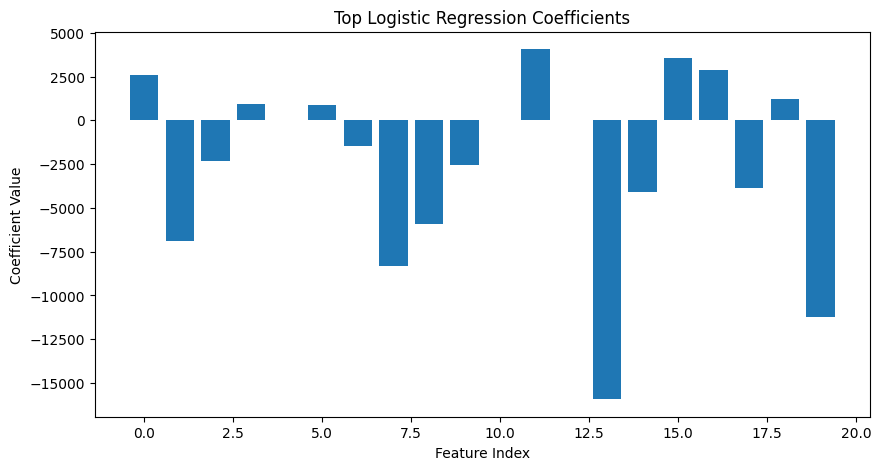

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Top coefficients
top_coeffs = coefficients[:20]

plt.figure(figsize=(10,5))
plt.bar(range(len(top_coeffs)), top_coeffs)

plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Top Logistic Regression Coefficients")

plt.show()